# Baseline ML Evaluation

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Colab setup

Mount the project Google Drive and verify:

```text
data/processed/cicids2017/
├── train.parquet
├── validation.parquet
├── test.parquet
├── feature_columns.json
└── label_mapping.json
```

In [6]:
from pathlib import Path
import json, time, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount("/content/drive")

REPO = Path("/content/drive/MyDrive/CIC-Dataset-Analysis")
DATA_DIR = REPO / "data/processed/cicids2017"
OUT_DIR = REPO / "results/ml_baseline"
OUT_DIR.mkdir(parents=True, exist_ok=True)

required = ["train.parquet","validation.parquet","test.parquet","feature_columns.json","label_mapping.json"]
missing = [x for x in required if not (DATA_DIR/x).exists()]
if missing:
    raise FileNotFoundError(f"Missing processed artifacts: {missing}. Run Notebook 14 first.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Load processed data

The processed dataset is already scaled. Do not fit another scaler here. For reproducibility and Colab feasibility, the baseline stage uses a bounded, stratified training sample; the held-out validation/test sets are not resampled.

In [7]:
from sklearn.model_selection import train_test_split

train = pd.read_parquet(DATA_DIR / "train.parquet")
val = pd.read_parquet(DATA_DIR / "validation.parquet")
test = pd.read_parquet(DATA_DIR / "test.parquet")

with open(DATA_DIR / "feature_columns.json") as f:
    features = json.load(f)

with open(DATA_DIR / "label_mapping.json") as f:
    label_mapping = json.load(f)

# Bound baseline training cost while retaining all validation/test rows.
MAX_BASELINE_TRAIN_ROWS = 500_000

if len(train) > MAX_BASELINE_TRAIN_ROWS:
    train_fit, _ = train_test_split(
        train,
        train_size=MAX_BASELINE_TRAIN_ROWS,
        stratify=train["label"],
        random_state=42
    )
else:
    train_fit = train.copy()

X_train, y_train = train_fit[features], train_fit["label"]
X_val, y_val = val[features], val["label"]
X_test, y_test = test[features], test["label"]

print("Full train:", train.shape)
print("Baseline fit sample:", train_fit.shape)
print("Validation:", val.shape)
print("Test:", test.shape)
print("Classes:", len(label_mapping))

Full train: (1981520, 79)
Baseline fit sample: (500000, 79)
Validation: (424611, 79)
Test: (424612, 79)
Classes: 15


## 2. Establish class-support diagnostics

The EDA identified strong class imbalance. Record the support before fitting models so performance can be interpreted in context.

In [8]:
support = pd.DataFrame({
    "train": y_train.value_counts(),
    "validation": y_val.value_counts(),
    "test": y_test.value_counts()
}).fillna(0).astype(int).sort_index()

display(support)
support.to_csv(OUT_DIR/"class_support.csv")

,train,validation,test
label,,,
0,401502,340964,340965
1,347,295,295
2,22614,19204,19204
3,1818,1544,1544
4,40815,34661,34661
5,971,825,825
6,1024,870,869
7,1402,1190,1191
8,2,2,1


## 3. Baselines

Evaluate:

1. Dummy majority classifier — establishes the accuracy floor/majority-class baseline.
2. Logistic Regression — linear baseline.
3. Random Forest — nonlinear tree baseline.

The purpose is not exhaustive model search. It is to establish whether the feature space contains usable signal and where the initial bottleneck lies.

In [9]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    precision_score, recall_score, classification_report,
    confusion_matrix
)

models = {
    "DummyMajority": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression": LogisticRegression(
        max_iter=1000, n_jobs=None, class_weight="balanced"
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample",
        max_features="sqrt"
    )
}

results=[]
reports={}

for name, model in models.items():
    print("\nFitting", name)
    start=time.perf_counter()
    model.fit(X_train, y_train)
    fit_time=time.perf_counter()-start

    pred=model.predict(X_val)
    results.append({
        "model":name,
        "accuracy":accuracy_score(y_val,pred),
        "balanced_accuracy":balanced_accuracy_score(y_val,pred),
        "macro_precision":precision_score(y_val,pred,average="macro",zero_division=0),
        "macro_recall":recall_score(y_val,pred,average="macro",zero_division=0),
        "macro_f1":f1_score(y_val,pred,average="macro",zero_division=0),
        "weighted_f1":f1_score(y_val,pred,average="weighted",zero_division=0),
        "fit_seconds":fit_time
    })
    reports[name]=classification_report(y_val,pred,output_dict=True,zero_division=0)

baseline_results=pd.DataFrame(results).sort_values("macro_f1",ascending=False)
display(baseline_results)
baseline_results.to_csv(OUT_DIR/"model_comparison.csv",index=False)


Fitting DummyMajority

Fitting LogisticRegression

Fitting RandomForest


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,fit_seconds
2,RandomForest,0.998309,0.812777,0.868928,0.812777,0.833045,0.998259,257.919528
1,LogisticRegression,0.842703,0.852806,0.374114,0.852806,0.449753,0.888444,701.539864
0,DummyMajority,0.803003,0.066667,0.053534,0.066667,0.059383,0.715267,0.021061


## 4. Per-class evaluation

Macro averages can still hide which specific attacks are failing. Export class-level metrics for the dashboard/report.

In [10]:
per_class=[]
for name, model in models.items():
    pred=model.predict(X_val)
    report=classification_report(
        y_val,pred,output_dict=True,zero_division=0
    )
    for cls, metrics in report.items():
        if cls.isdigit():
            per_class.append({
                "model":name,
                "label_id":int(cls),
                "precision":metrics["precision"],
                "recall":metrics["recall"],
                "f1":metrics["f1-score"],
                "support":metrics["support"]
            })

per_class_df=pd.DataFrame(per_class)
display(per_class_df.head(30))
per_class_df.to_csv(OUT_DIR/"per_class_metrics.csv",index=False)

,model,label_id,precision,recall,f1,support
0,DummyMajority,0,0.803003,1.000000,0.890740,340964.0
1,DummyMajority,1,0.000000,0.000000,0.000000,295.0
2,DummyMajority,2,0.000000,0.000000,0.000000,19204.0
3,DummyMajority,3,0.000000,0.000000,0.000000,1544.0
4,DummyMajority,4,0.000000,0.000000,0.000000,34661.0
5,DummyMajority,5,0.000000,0.000000,0.000000,825.0
6,DummyMajority,6,0.000000,0.000000,0.000000,870.0
7,DummyMajority,7,0.000000,0.000000,0.000000,1190.0
8,DummyMajority,8,0.000000,0.000000,0.000000,2.0
9,DummyMajority,9,0.000000,0.000000,0.000000,6.0


## 5. Confusion matrix for the best validation model

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
true_label,,,,,,,,,,,,,,,
0,340727,29,3,2,73,4,0,0,0,0,125,0,1,0,0
1,93,202,0,0,0,0,0,0,0,0,0,0,0,0,0
2,11,0,19192,0,1,0,0,0,0,0,0,0,0,0,0
3,2,0,0,1539,3,0,0,0,0,0,0,0,0,0,0
4,80,0,1,1,34579,0,0,0,0,0,0,0,0,0,0
5,4,0,0,0,0,815,6,0,0,0,0,0,0,0,0
6,3,0,0,0,0,1,865,0,0,0,0,0,1,0,0
7,1,0,0,0,0,0,0,1189,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0


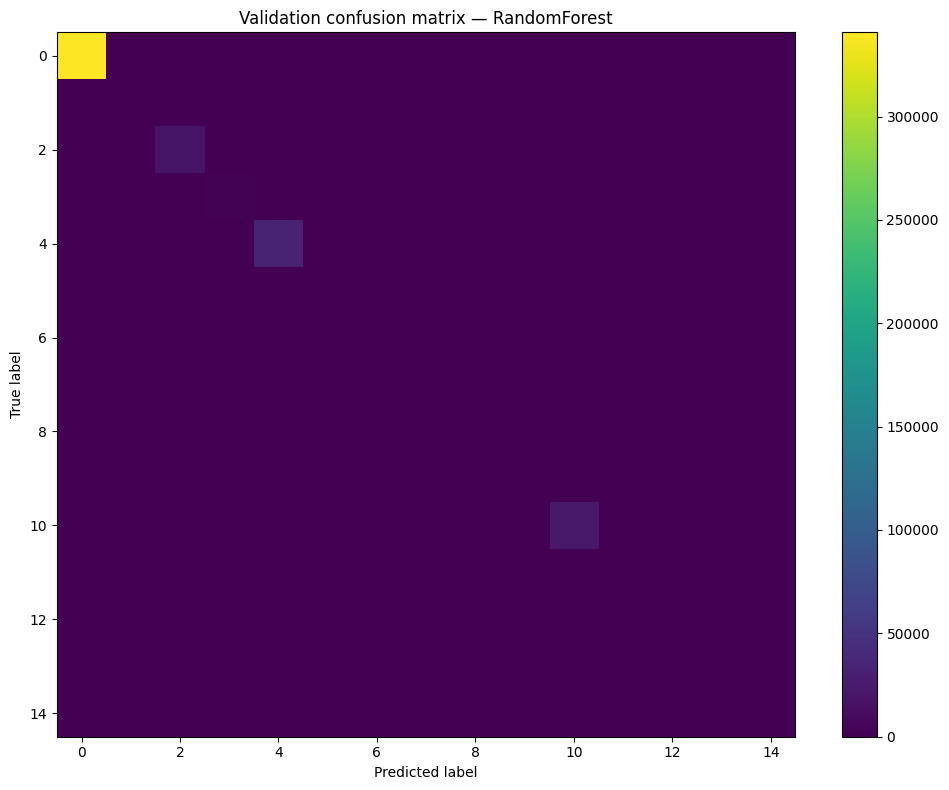

In [11]:
best_name=baseline_results.iloc[0]["model"]
best_model=models[best_name]
val_pred=best_model.predict(X_val)

cm=confusion_matrix(y_val,val_pred,labels=sorted(label_mapping.values()))
cm_df=pd.DataFrame(cm,index=sorted(label_mapping.values()),columns=sorted(label_mapping.values()))
cm_df.index.name="true_label"
cm_df.to_csv(OUT_DIR/"confusion_matrix.csv")
display(cm_df)

plt.figure(figsize=(10,8))
plt.imshow(cm, aspect="auto")
plt.title(f"Validation confusion matrix — {best_name}")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.colorbar()
plt.tight_layout()
plt.show()

## 6. Save the best baseline model

The selected baseline is chosen by **validation macro F1**, not accuracy.

> The baseline model is selected using the bounded training sample and the full validation split. Notebook 16 then evaluates that frozen selection on the untouched test set.

In [12]:
import joblib
joblib.dump(best_model, OUT_DIR/f"{best_name}.joblib")

with open(OUT_DIR/"selected_baseline.json","w") as f:
    json.dump({
        "model":best_name,
        "selection_metric":"validation_macro_f1",
        "validation_macro_f1":float(baseline_results.iloc[0]["macro_f1"])
    },f,indent=2)

print("Selected:",best_name)

Selected: RandomForest


## Conclusion

The baseline machine-learning evaluation establishes an initial reference point for assessing the practical modelling suitability of the selected CIC dataset.

The experiments demonstrate that the dataset contains sufficient labelled traffic to support supervised intrusion-detection modelling, while also confirming that the modelling problem is affected by the data characteristics identified during the preceding analysis stages. In particular, class imbalance, highly skewed numerical features, duplicated observations, correlated features, extreme values, and the uneven distribution of attack categories remain important considerations when interpreting baseline performance.

The baseline results should therefore be treated as a **reference benchmark rather than the final IDS performance**. High aggregate accuracy alone is not sufficient evidence of a useful intrusion-detection model, particularly when BENIGN traffic constitutes the majority class. Class-wise precision, recall, F1-score, confusion matrices, and minority-class behaviour provide a more meaningful assessment of whether attacks are being detected reliably.

The results from this notebook provide the quantitative baseline against which the subsequent preprocessing, feature-selection, balancing, and modelling experiments can be compared. Any improvement in later experiments should be evaluated against these baseline results using the same evaluation protocol to ensure that the comparison remains meaningful.

Overall, the baseline evaluation confirms that the selected dataset is **ML-usable but not modelling-ready without further treatment**. The next stage should therefore focus on constructing a reproducible preprocessing pipeline, addressing problematic numerical values and redundant features, applying an appropriate strategy for class imbalance, and evaluating models using metrics that reflect the requirements of an IDS rather than relying primarily on overall accuracy.

This notebook consequently serves as the transition between the exploratory dataset-analysis phase and the experimental machine-learning phase of the project.